# 实验7 自然语言处理之语义相似度分析

## 1. 余弦相似度和广义Jaccard相似度

根据下面的表格，计算苹果和大米的余弦相似度和广义Jaccard相似度。

| 词频 | 水果 | 公司 | 手机 | 粮食 |
|------|------|------|------|------|
| 橘子 | 0.92 | 0.23 | 0.02 | 0.19 |
| 香蕉 | 0.95 | 0.13 | 0.09 | 0.25 |
| 苹果 | 0.96 | 0.77 | 0.85 | 0.15 |
| 小米 | 0.08 | 0.81 | 0.98 | 0.87 |
| 华为 | 0.02 | 0.93 | 0.95 | 0.01 |
| 大米 | 0.18 | 0.22 | 0.05 | 0.93 |



In [1]:
from sklearn.metrics.pairwise import cosine_similarity, pairwise_distances
import numpy as np


def generalized_jaccard_similarity(A, B):
    # 计算点积
    dot_product = np.dot(A, B)
    # 计算A和B的范数的平方
    norm_A_squared = np.dot(A, A)
    norm_B_squared = np.dot(B, B)
    # 计算广义Jaccard相似度
    similarity = dot_product / (norm_A_squared * norm_B_squared - dot_product)
    return similarity


a = np.array([0.96, 0.77, 0.85, 0.15])
b = np.array([0.18, 0.22, 0.05, 0.93])
# 余弦相似度
print(cosine_similarity([a], [b]))
# 广义Jaccard相似度
print(generalized_jaccard_similarity(a, b))

[[0.35813014]]
0.32392859012151265


## 2. 词袋模型实践

### （1） 准备工作

首先导入所需的模块，然后准备需要计算相似度的句子。在这个例子中，我们将使用`CountVectorizer`来构建词袋模型，并通过`cosine_similarity`来计算句子之间的相似度。大家可以自行输入两个相似但不相同的两个中文句子。

In [2]:
from sklearn.feature_extraction.text import CountVectorizer 
from sklearn.metrics.pairwise import cosine_similarity 

# 输入的两个句子 
sentence1 = "出牌阶段限一次，你可以弃置至多三张牌，然后摸等量的牌" 
sentence2 = "出牌阶段限一次，你可以摸至多三张牌，然后弃置等量的牌"

### （2） 分词

下面对中文句子进行分词。

In [3]:
import jieba

# 使用jieba进行分词
def jieba_cut(sentence):
    return " ".join(jieba.cut(sentence))


sentence1_cut = jieba_cut(sentence1)
sentence2_cut = jieba_cut(sentence2)
print(sentence1_cut)
print(sentence2_cut)

Building prefix dict from the default dictionary ...
Loading model from cache C:\Users\zhjw\AppData\Local\Temp\jieba.cache
Loading model cost 0.507 seconds.
Prefix dict has been built successfully.


出 牌 阶段 限 一次 ， 你 可以 弃置 至多 三张 牌 ， 然后 摸 等量 的 牌
出 牌 阶段 限 一次 ， 你 可以 摸 至多 三张 牌 ， 然后 弃置 等量 的 牌


### （3） 构建词袋模型

首先需要把句子转化为词袋模型，每个句子的词袋模型是一个向量，向量的每个维度对应词汇表中的一个词，值是该词在句子中的出现频率。

In [4]:
# 使用CountVectorizer构建词袋模型
vectorizer = CountVectorizer()
# 将两个句子转换为词袋向量
X = vectorizer.fit_transform([sentence1_cut, sentence2_cut])

### （4） 计算余弦相似度

通过计算两个向量之间的余弦相似度，我们可以衡量两个句子在词袋空间中的相似度。

In [5]:
# 计算余弦相似度
cosine_sim = cosine_similarity(X[0:1], X[1:2])

# 输出相似度
print(f"两个句子的余弦相似度为: {cosine_sim[0][0]:.4f}")

两个句子的余弦相似度为: 1.0000


可以看到，词袋模型对于一些更换顺序的专业术语描述没有任何用处，因为它只关心词汇表中的词是否出现，而不关心词的顺序。

参考上述代码，尝试构建两句话以上的词袋模型并计算相似度

In [6]:
sentences = [
    "结束阶段，你可以摸一张牌",
    "一名角色的结束阶段，你可以摸一张牌",
    "一名其他角色的结束阶段，你可以摸一张牌",
    "结束阶段，你可以令一名角色摸一张牌",
    "结束阶段，你可以令一名其他角色摸一张牌",
]

sentences_cut = [jieba_cut(sentence) for sentence in sentences]
for ele in sentences_cut:
    print(ele)

结束 阶段 ， 你 可以 摸 一张 牌
一名 角色 的 结束 阶段 ， 你 可以 摸 一张 牌
一名 其他 角色 的 结束 阶段 ， 你 可以 摸 一张 牌
结束 阶段 ， 你 可以 令 一名 角色 摸 一张 牌
结束 阶段 ， 你 可以 令 一名 其他 角色 摸 一张 牌


In [7]:
# 使用CountVectorizer构建词袋模型
vectorizer = CountVectorizer()
# 将两个句子转换为词袋向量
X = vectorizer.fit_transform(sentences_cut)
# 计算两两句子之间的余弦相似度
cosine_sim = cosine_similarity(X)
print(cosine_sim)

[[1.         0.81649658 0.75592895 0.81649658 0.75592895]
 [0.81649658 1.         0.9258201  1.         0.9258201 ]
 [0.75592895 0.9258201  1.         0.9258201  1.        ]
 [0.81649658 1.         0.9258201  1.         0.9258201 ]
 [0.75592895 0.9258201  1.         0.9258201  1.        ]]


很显然这几句话是不同的意思，但词袋模型却认为有几句话的意思是一样的。由此可见，词袋模型的缺点暴露无遗。

## 3. 使用Word2Vec计算文本相似度

### （1） 准备工作

首先导入所需库。我们利用`jieba`库来对中文句子进行分词，它能够将句子分解成一个个词语；`gensim.models.Word2Vec`用来训练`Word2Vec`模型；`cosine_similarity`用于计算句子之间的余弦相似度。

In [8]:
import jieba
from gensim.models import Word2Vec
from sklearn.metrics.pairwise import cosine_similarity

接下来准备句子数据，可以用下面提供的，也可以自行定义。

In [9]:
sentences = [
    "结束阶段，你可以摸一张牌",
    "一名角色的结束阶段，你可以摸一张牌",
    "一名其他角色的结束阶段，你可以摸一张牌",
    "结束阶段，你可以令一名角色摸一张牌",
    "结束阶段，你可以令一名其他角色摸一张牌",
]

### （2） 分词

将输入的句子列表进行中文分词，并输出每个句子的分词结果。

In [10]:
# 使用jieba对句子进行分词
def cut_sentences(sentences):
    return [list(jieba.cut(sentence)) for sentence in sentences]


tokenized_sentences = cut_sentences(sentences)

# 打印分词后的结果
for sentence in tokenized_sentences:
    print(" ".join(sentence))

结束 阶段 ， 你 可以 摸 一张 牌
一名 角色 的 结束 阶段 ， 你 可以 摸 一张 牌
一名 其他 角色 的 结束 阶段 ， 你 可以 摸 一张 牌
结束 阶段 ， 你 可以 令 一名 角色 摸 一张 牌
结束 阶段 ， 你 可以 令 一名 其他 角色 摸 一张 牌


### （3） 模型训练

`Word2Vec`是一个将单词转换为向量的模型，训练时会从文本中学习词与词之间的语义关系。

In [11]:
# 训练Word2Vec模型
model = Word2Vec(tokenized_sentences, window=5, min_count=1, sg=0)

### （4） 计算句子向量

 计算每个句子的词向量平均值，作为句子的向量表示。

In [12]:
import numpy as np

# 计算句子向量
def sentence_vector(tokens):
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    return np.mean(vectors, axis=0) if vectors else np.zeros(100)


# 获取每个句子的词向量
sentence_vectors = [sentence_vector(sentence)
                    for sentence in tokenized_sentences]

### （5） 计算相似度

利用`cosine_similarity`来计算句子之间的余弦相似度。

In [13]:
# 计算余弦相似度
from sklearn.metrics.pairwise import cosine_similarity
cosine_sim = cosine_similarity(sentence_vectors)
cosine_sim

array([[1.0000001 , 0.86051464, 0.84597546, 0.8450855 , 0.82151943],
       [0.86051464, 0.9999999 , 0.96500736, 0.919301  , 0.8788404 ],
       [0.84597546, 0.96500736, 0.99999994, 0.9019319 , 0.9309446 ],
       [0.8450855 , 0.919301  , 0.9019319 , 1.        , 0.9649879 ],
       [0.82151943, 0.8788404 , 0.9309446 , 0.9649879 , 0.9999999 ]],
      dtype=float32)

### （6） 可视化结果

可以用热图来可视化结果，热图中的每个格子表示两个句子之间的余弦相似度。

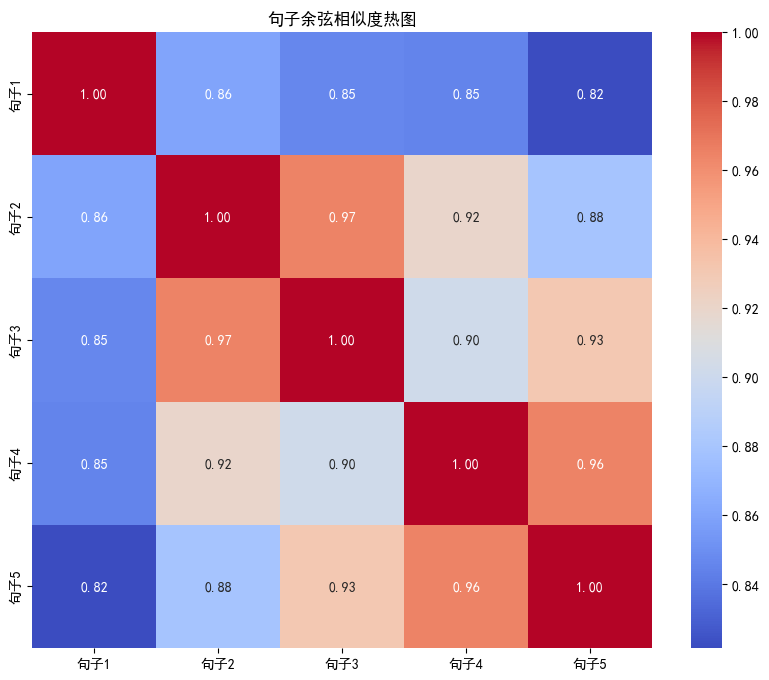

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams["font.sans-serif"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False
plt.figure(figsize=(10, 8))
sns.heatmap(cosine_sim, annot=True, cmap="coolwarm", xticklabels=[f"句子{i+1}" for i in range(
    len(sentences))], yticklabels=[f"句子{i+1}" for i in range(len(sentences))], fmt=".2f")
plt.title("句子余弦相似度热图")
plt.show()